# Introdução ao Projeto: Análise Exploratória de Dados

## Contexto  
Este projeto tem como base um dataset de previsão de vendas disponível no Kaggle https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting. O conjunto de dados reúne informações detalhadas sobre transações, desempenho financeiro e outros indicadores comerciais, permitindo uma análise aprofundada dos padrões de vendas e das variações do mercado.

## Problema  
Os dados revelam variações significativas entre diferentes categorias, regiões e períodos. Essa variedade torna desafiador identificar os fatores-chave que impulsionam o desempenho e a rentabilidade, exigindo uma análise criteriosa para extrair insights relevantes.

## Objetivo  
O objetivo principal deste projeto é conduzir uma Análise Exploratória de Dados (EDA) completa, que permita:
- Compreender a dinâmica e distribuição das vendas;
- Identificar tendências e padrões relevantes;
- Reconhecer oportunidades de melhoria e áreas com potencial de crescimento.

## Etapas do Projeto  
- **Importação e Compreensão dos Dados:** Carregar o dataset e realizar uma análise inicial para entender a estrutura, dimensões e principais variáveis.  
- **Limpeza e Tratamento dos Dados:** Detectar e corrigir inconsistências, além de tratar valores ausentes para garantir a confiabilidade da análise.  
- **Análise Estatística Descritiva:** Aplicar técnicas de resumo estatístico para captar as características essenciais dos dados.  
- **Visualizações Interativas:** Desenvolver gráficos e dashboards para uma exploração visual eficaz dos padrões e tendências.  
- **Geração de Insights e Recomendações:** Traduzir os achados da análise em insights que possam gerar decisões estratégicas.


##  Configuração do Ambiente

### Instalação das Bibliotecas

In [2]:
%pip install pandas numpy matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


### Importação das Bibliotecas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Carregamento e Inspeção dos Dados

### Carregamento do Dataset

In [4]:
caminho = './data/train.csv'

df = pd.read_csv("./data/train.csv")
df_original = df.copy() 

print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")
df.head()

Dimensões do dataset: 9800 linhas e 18 colunas


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Examinando Informações do Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Estatísticas Descritivas

In [6]:
# Estatísticas descritivas para variáveis numéricas
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
# Estatísticas descritivas para variáveis categóricas
df.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


### Identificação de Valores Ausentes
Verificamos a quantidade e a proporção de valores ausentes em cada coluna.

In [ ]:
# Calculando valores ausentes
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Criando um dataframe para visualizar os valores ausentes
missing_df = pd.DataFrame({
    'Valores Ausentes': missing_values,
    'Porcentagem (%)': missing_percent
})

# Exibindo apenas colunas com valores ausentes
missing_df = missing_df[missing_df['Valores Ausentes'] > 0].sort_values('Porcentagem (%)', ascending=False)
missing_df

,Valores Ausentes,Porcentagem (%)
Postal Code,11,0.112245


In [9]:
# Contar valores ausentes por coluna
missing_count = df.isnull().sum()
print(missing_count[missing_count > 0])

Postal Code    11
dtype: int64


In [10]:
# Filtra e exibe todas as linhas do DataFrame onde a coluna 'Postal Code' está com valor ausente (NaN)
df[df['Postal Code'].isna()]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


Identificamos que todos os registros com valores NaN na coluna 'Postal Code' correspondem exclusivamente ao estado de Vermont na região Leste.

### Tratamento de Valores Ausentes
Preenchemos os valores ausentes com o código 5001, que corresponde a um código postal comum utilizado em Burlington, Vermont. Esta abordagem foi escolhida por ser a principal cidade do estado, garantindo consistência nos dados.

In [11]:
# Verificando padrões nos códigos postais
print(f"Valores únicos em Postal Code: {df['Postal Code'].nunique()}")

# preenchendo valores ausentes com o código postal de vermont
df['Postal Code'] = df['Postal Code'].fillna(5001)
print(f"Preenchidos valores ausentes com o Postal Code de Vermont: {5001}")

# Verificando se ainda existem valores ausentes
print(f"Valores ausentes restantes: {df.isnull().sum().sum()}")

Valores únicos em Postal Code: 626
Preenchidos valores ausentes com o Postal Code de Vermont: 5001
Valores ausentes restantes: 0


### Verificação de linhas duplicadas

In [ ]:
duplicates = df.duplicated()
total_duplicates = duplicates.sum()
print(f"Total de linhas duplicadas no dataset: {total_duplicates}")

Total de linhas duplicadas no dataset: 0


## Análise de Variáveis Categóricas

### Identificação de Variáveis Categóricas

In [ ]:
# Identificando variáveis categóricas
cat_columns = df.select_dtypes(include=['object']).columns.tolist()
print(f"Variáveis categóricas: {cat_columns}")

Variáveis categóricas: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']


### Distribuição de Categorias

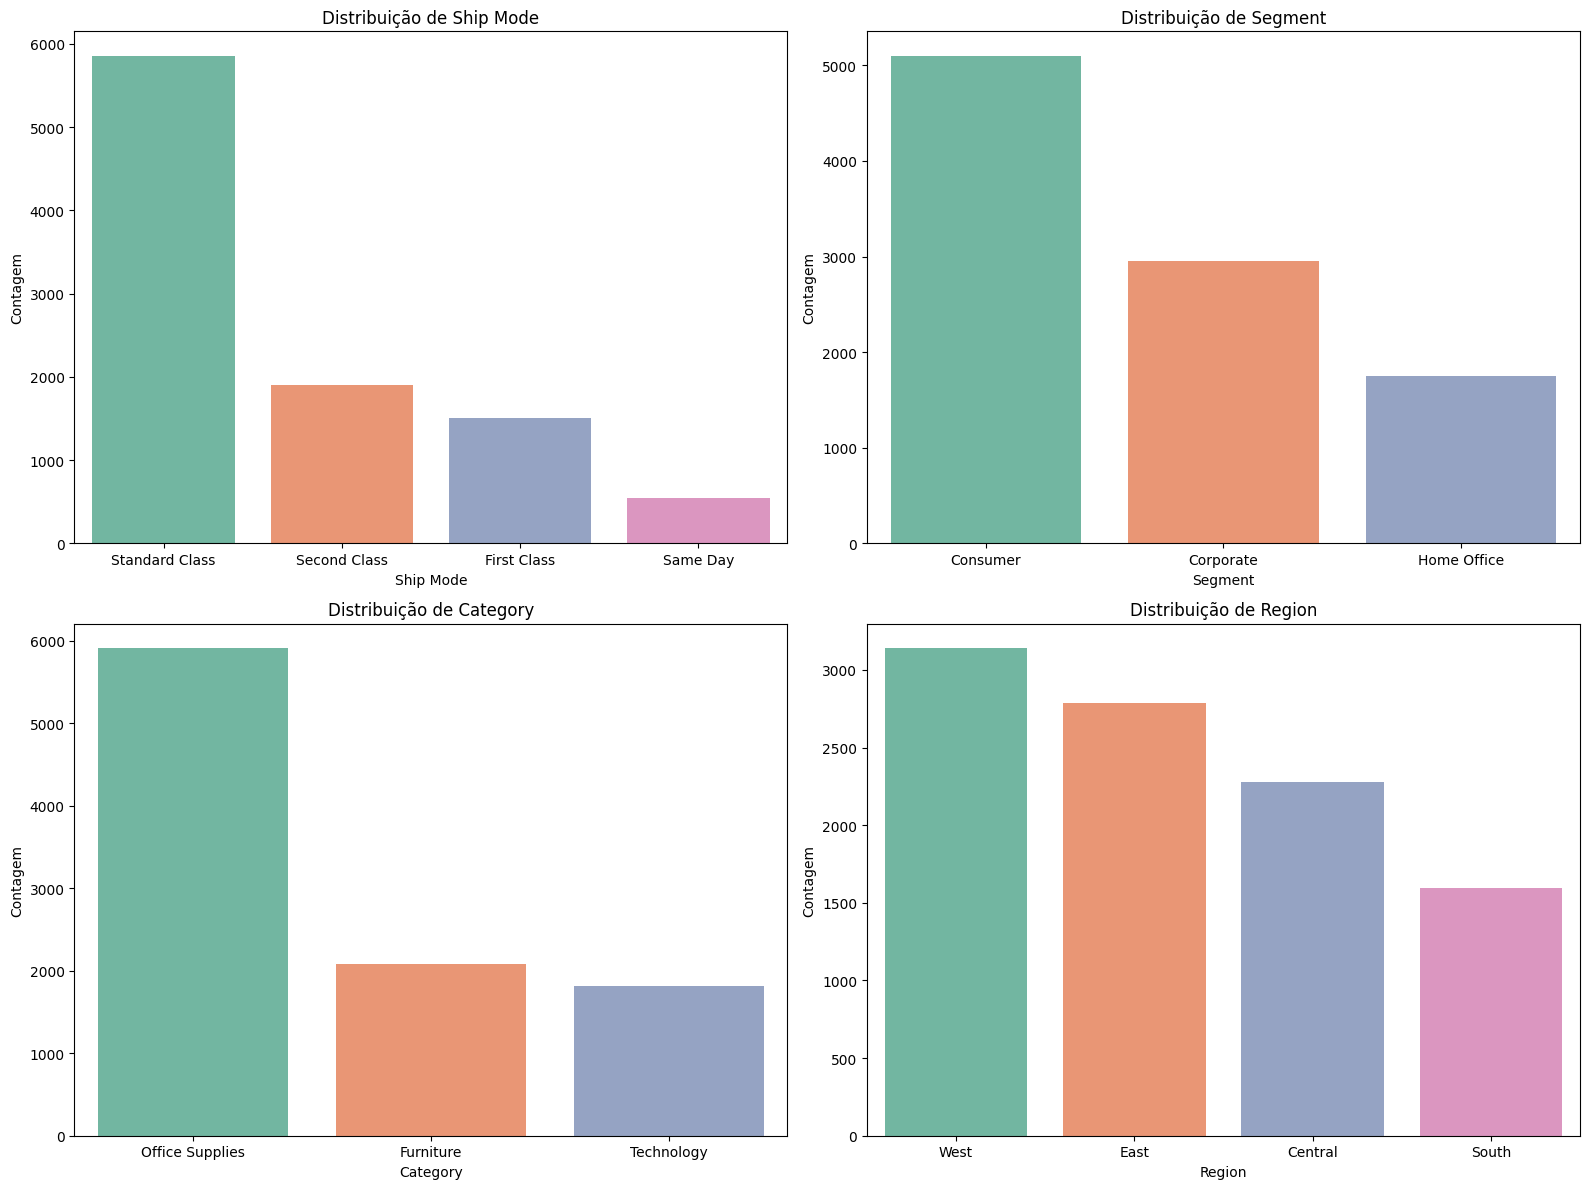

In [25]:


def plot_categorical_distribution(ax, df, column_name, palette_name="Set2"):
    counts = df[column_name].value_counts().sort_values(ascending=False).reset_index()
    counts.columns = [column_name, 'count']  # renomeia colunas para clareza

    palette = sns.color_palette(palette_name, n_colors=len(counts))

    sns.barplot(data=counts, x=column_name, y='count', hue=column_name, 
                ax=ax, palette=palette, legend=False)
    
    ax.set_title(f'Distribuição de {column_name}', fontsize=12)
    ax.set_ylabel('Contagem')
    ax.set_xlabel(column_name)
    ax.tick_params(axis='x')

# Criando o grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Lista de variáveis categóricas e seus respectivos eixos
variaveis = ['Ship Mode', 'Segment', 'Category', 'Region']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

# Gerando os gráficos com a função
for var, pos in zip(variaveis, positions):
    plot_categorical_distribution(axes[pos], df, var)

plt.tight_layout()
plt.show()


### Análise da Relação entre Variáveis Categóricas

In [28]:
# Criando uma tabela para analizar a relação entre Segment e Category
segment_category = pd.crosstab(df['Segment'], df['Category'])
print("Tabela cruzada: Segment x Category")
segment_category

Tabela cruzada: Segment x Category


Category,Furniture,Office Supplies,Technology
Segment,,,
Consumer,1093,3072,936
Corporate,628,1783,542
Home Office,357,1054,335


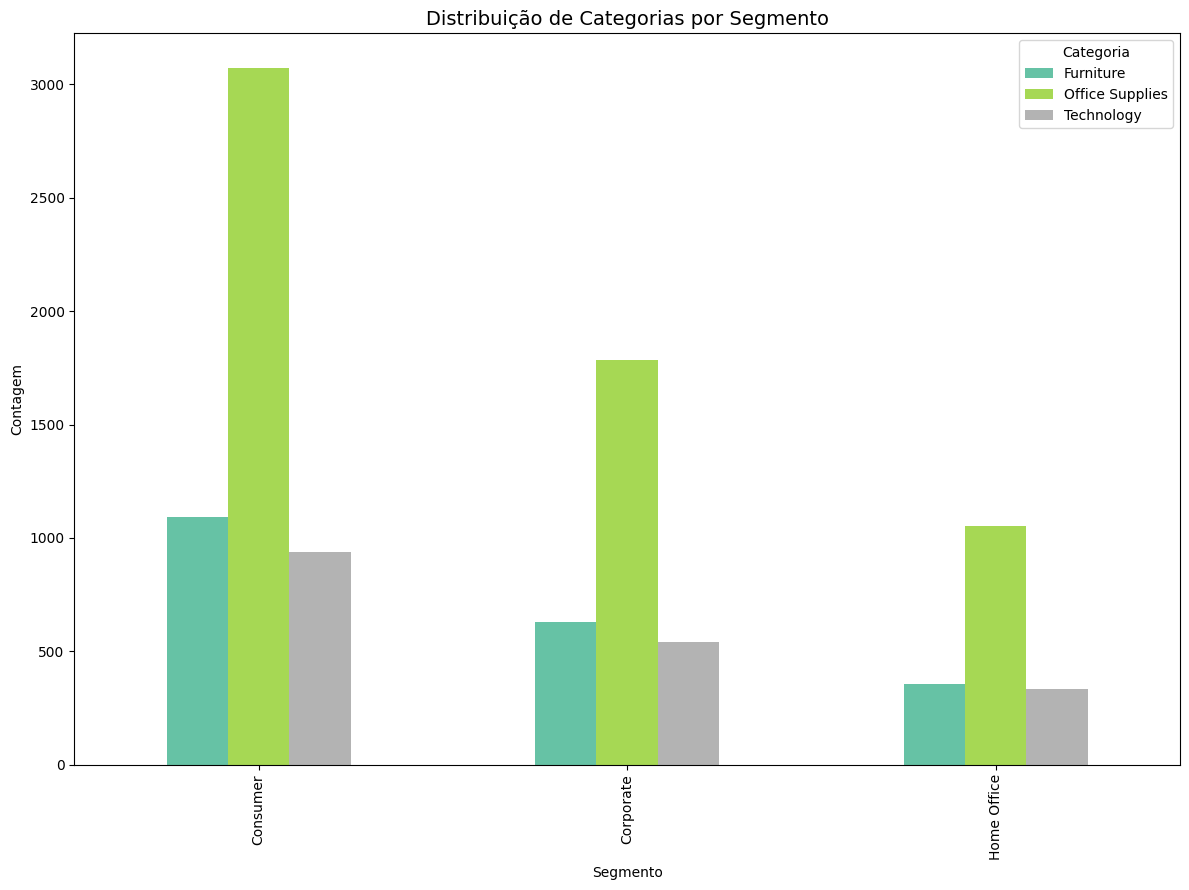

In [46]:
# Visualizando a relação entre Segment e Category
fig, ax = plt.subplots(figsize=(12, 9))  # Cria figura E eixos
segment_category.plot(kind='bar', colormap='Set2', ax=ax) 
plt.title('Distribuição de Categorias por Segmento', fontsize=14)
plt.xlabel('Segmento')
plt.ylabel('Contagem')
plt.legend(title='Categoria')
plt.tight_layout()
plt.show()

## Análise de Variáveis Numéricas

In [47]:
# Identificando variáveis numéricas
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Variáveis numéricas: {num_columns}")

Variáveis numéricas: ['Row ID', 'Postal Code', 'Sales']


### Distribuição de Variáveis Numéricas

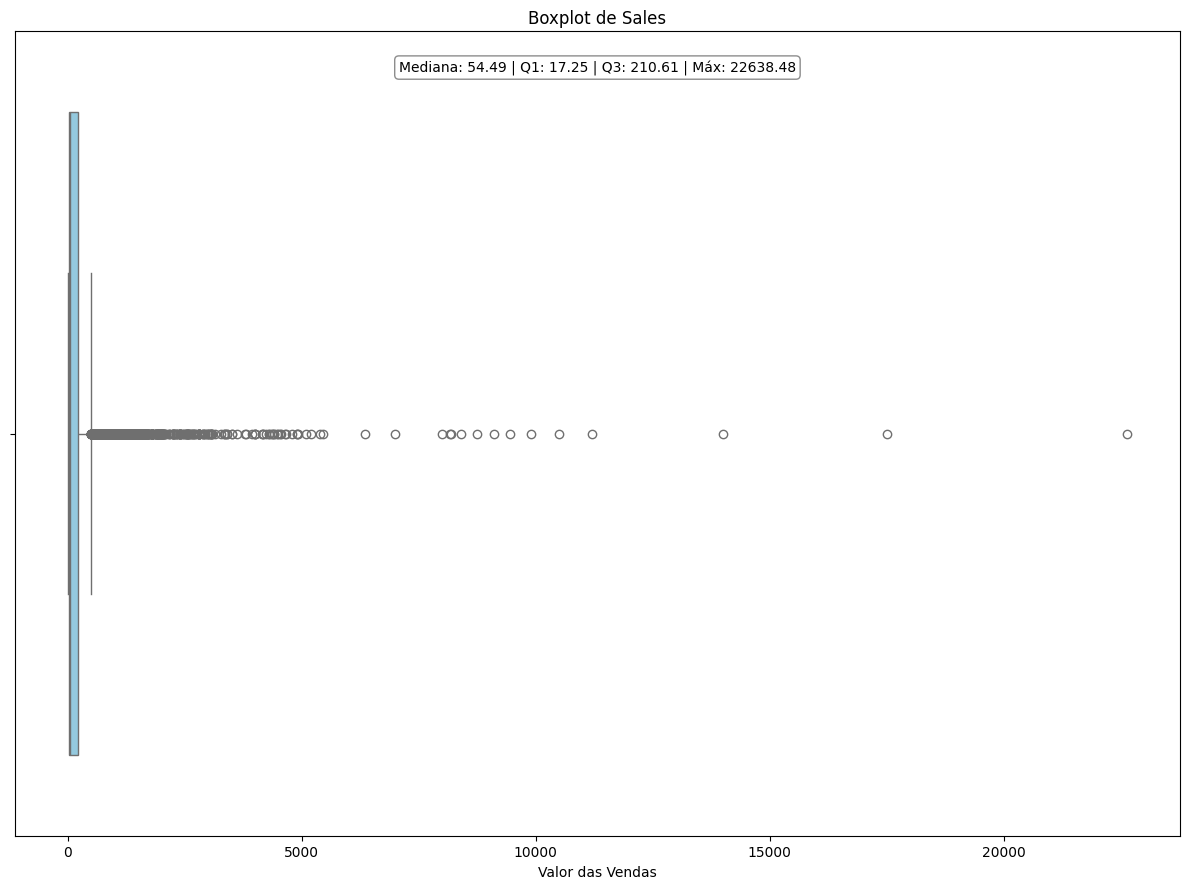

In [52]:
# Criar boxplot
plt.figure(figsize=(12, 9))
sns.boxplot(x=df['Sales'], color='skyblue')
plt.title('Boxplot de Sales')
plt.xlabel('Valor das Vendas')

# Anotação com estatísticas principais
stats = df['Sales'].describe()
info = f"Mediana: {stats['50%']:.2f} | Q1: {stats['25%']:.2f} | Q3: {stats['75%']:.2f} | Máx: {stats['max']:.2f}"
plt.annotate(info, xy=(0.5, 0.95), xycoords='axes fraction', ha='center',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.9))

plt.tight_layout()
plt.show()

### Análise Bivariada

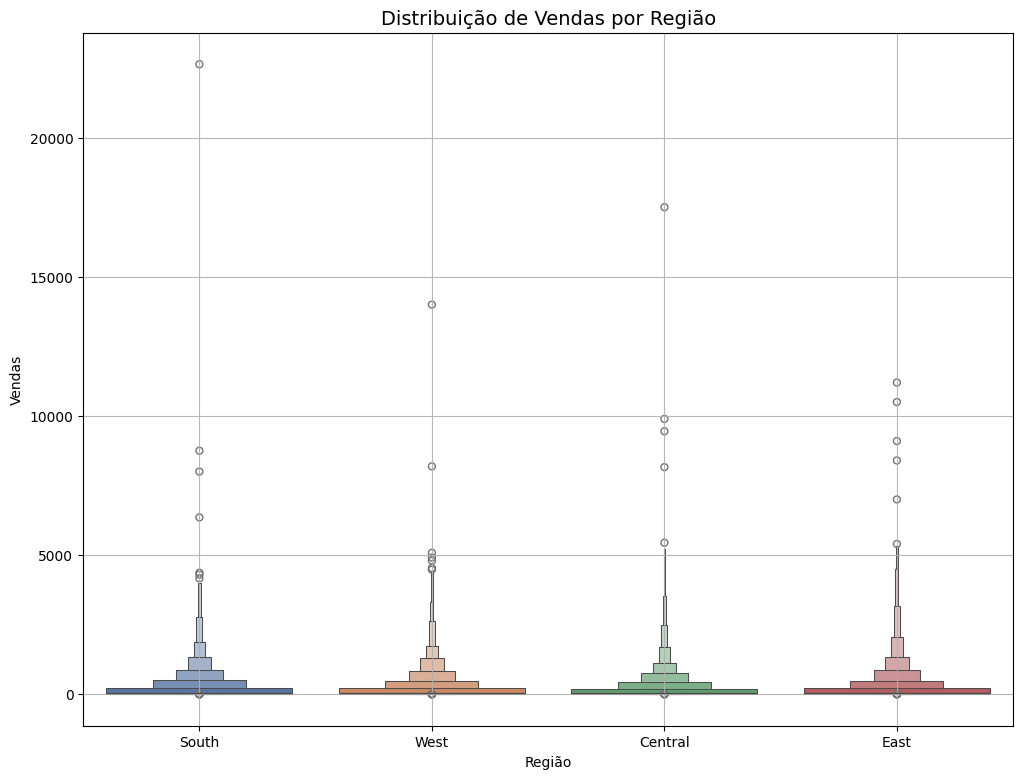

In [63]:
# Boxplots para vendas por região
plt.figure(figsize=(12, 9))
sns.boxenplot(x='Region', hue='Region', y='Sales', data=df, palette='deep', legend=False)
plt.title('Distribuição de Vendas por Região', fontsize=14)
plt.xlabel('Região')
plt.ylabel('Vendas')
plt.grid(True, alpha=0.9)
plt.show()